# BTC Mean Reversion Single Asset

In [1]:
from datetime import UTC, datetime

import data
import research

In [2]:
research.set_seed(123)

sym = "BTCUSDT"
interval = "1h"
max_lags = 4
forecast_horizon = 1
annualized_rate = research.sharpe_to_annualized_rate(interval, 365, 24)
start_date = datetime(2025, 1, 1, 0, 0, tzinfo=UTC)
end_date = datetime(2026, 1, 1, 0, 0, tzinfo=UTC)

data.download_date_range(sym, start_date, end_date)

In [3]:
ts = research.load_ohlc_timeseries_range(sym, interval, start_date, end_date)
ts

Loading BTCUSDT:   0%|          | 0/366 [00:00<?, ?day/s]

Loading BTCUSDT:   0%|          | 1/366 [00:00<02:36,  2.32day/s]

Loading BTCUSDT:   1%|          | 2/366 [00:00<02:40,  2.27day/s]

Loading BTCUSDT:   1%|          | 3/366 [00:01<02:30,  2.42day/s]

Loading BTCUSDT:   1%|          | 4/366 [00:01<02:04,  2.91day/s]

...

Loading BTCUSDT:  99%|█████████▉| 364/366 [03:10<00:00,  2.72day/s]

Loading BTCUSDT: 100%|█████████▉| 365/366 [03:11<00:00,  2.87day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:11<00:00,  3.45day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:11<00:00,  1.91day/s]

datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616
…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263


In [4]:
import polars as pl

research.load_timeseries_range(
    sym,
    interval,
    start_date,
    end_date,
    pl.col("price").quantile(0.5).alias("price_median"),
)

Loading BTCUSDT:   0%|          | 0/366 [00:00<?, ?day/s]

Loading BTCUSDT:   0%|          | 1/366 [00:00<01:53,  3.21day/s]

Loading BTCUSDT:   1%|          | 2/366 [00:00<02:49,  2.15day/s]

Loading BTCUSDT:   1%|          | 3/366 [00:01<02:29,  2.42day/s]

Loading BTCUSDT:   1%|          | 4/366 [00:01<02:03,  2.94day/s]

...

Loading BTCUSDT:  99%|█████████▉| 364/366 [03:16<00:00,  2.59day/s]

Loading BTCUSDT: 100%|█████████▉| 365/366 [03:16<00:00,  2.87day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:17<00:00,  3.44day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:17<00:00,  1.86day/s]

datetime,price_median
datetime[μs],f64
2025-01-01 00:00:00,93856.8
2025-01-01 01:00:00,93918.3
2025-01-01 02:00:00,93744.3
2025-01-01 03:00:00,93826.0
2025-01-01 04:00:00,93663.3
…,…
2026-01-01 19:00:00,88214.4
2026-01-01 20:00:00,88282.7
2026-01-01 21:00:00,88327.8


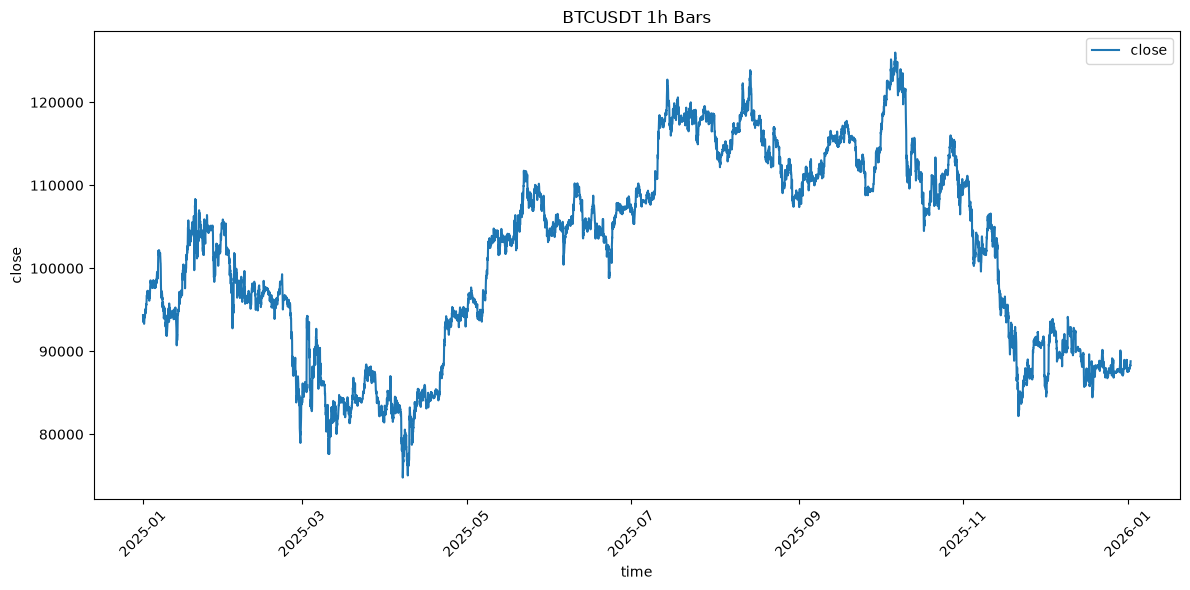

In [5]:
research.plot_timeseries(ts, sym, "close", interval)

In [6]:
import altair

altair.data_transformers.enable("vegafusion")
research.plot_timeseries(ts, sym, "close", interval, "dynamic")

alt.Chart(...)

In [7]:
ts = ts.with_columns(
    (pl.col("close") / pl.col("close").shift(forecast_horizon))
    .log()
    .alias("close_log_return")
)
ts

datetime,open,high,low,close,volume,close_log_return
datetime[μs],f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829
…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433


In [8]:
target = "close_log_return"
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon + 1).alias(f"{target}_t+{forecast_horizon + 1}"),
    lr.shift(forecast_horizon + 2).alias(f"{target}_t+{forecast_horizon + 2}"),
    lr.shift(forecast_horizon + 3).alias(f"{target}_t+{forecast_horizon + 3}"),
    lr.shift(forecast_horizon + 4).alias(f"{target}_t+{forecast_horizon + 4}"),
)
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null,null,null,null,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253,null,null,null,null
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077,null,null,null,null
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708,-0.008253,null,null,null
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829,0.005077,-0.008253,null,null
…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.003703,-0.000361,0.000787,0.000522
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.002147,-0.001315,0.003703,-0.000361


In [9]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,94363.6,5744.609,null,null,null,null,null,null,null,null,null
2025-01-01 01:00:00,94363.6,94363.7,93545.0,93588.0,3991.464,-0.008253,null,null,null,null,null,null,null,null
2025-01-01 02:00:00,93587.9,94082.4,93561.8,94064.4,2297.236,0.005077,null,null,null,null,-0.008253,null,null,null
2025-01-01 03:00:00,94064.4,94070.2,93692.6,93810.0,1928.71,-0.002708,-0.008253,null,null,null,0.005077,-0.008253,null,null
2025-01-01 04:00:00,93810.0,93810.1,93502.0,93545.0,2241.616,-0.002829,0.005077,-0.008253,null,null,-0.002708,0.005077,-0.008253,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.003703,-0.000361,0.000787,0.000522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001315,0.003703,-0.000361,0.000787,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.002147,-0.001315,0.003703,-0.000361,-0.001522,0.002147,-0.001315,0.003703


In [10]:
ts = ts.drop_nulls()
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 06:00:00,93760.0,93760.0,93533.3,93734.2,1970.927,-0.000275,-0.002829,-0.002708,0.005077,-0.008253,0.002296,-0.002829,-0.002708,0.005077
2025-01-01 07:00:00,93734.2,93785.4,93627.7,93660.7,1157.915,-0.000784,0.002296,-0.002829,-0.002708,0.005077,-0.000275,0.002296,-0.002829,-0.002708
2025-01-01 08:00:00,93660.7,93735.2,93258.8,93398.2,3525.325,-0.002807,-0.000275,0.002296,-0.002829,-0.002708,-0.000784,-0.000275,0.002296,-0.002829
2025-01-01 09:00:00,93398.2,93462.9,92796.5,93382.1,8669.812,-0.000172,-0.000784,-0.000275,0.002296,-0.002829,-0.002807,-0.000784,-0.000275,0.002296
2025-01-01 10:00:00,93382.1,93510.0,93250.1,93307.7,2989.11,-0.000797,-0.002807,-0.000784,-0.000275,0.002296,-0.000172,-0.002807,-0.000784,-0.000275
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.003703,-0.000361,0.000787,0.000522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001315,0.003703,-0.000361,0.000787,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.002147,-0.001315,0.003703,-0.000361,-0.001522,0.002147,-0.001315,0.003703


In [11]:
research.plot_distribution(ts, target, no_bins=100)

alt.Chart(...)

In [12]:
research.plot_distribution(ts, "close", no_bins=100)
# This is why we use log returns instead of raw prices.
# The distribution of log returns is more Gaussian-like, which is a common assumption in many financial models.

alt.Chart(...)

In [13]:
from torch import nn


class LinearModel(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        # this function defines the forward pass of the model,
        # which is how the input data flows through the model to produce an output
        return self.linear(x)

In [14]:
input_features = 1
linear_model = LinearModel(input_features)

# Count all parameters in the model
total_params = sum(p.numel() for p in linear_model.parameters())

# Count only parameters that will be updated during training
trainable_params = sum(p.numel() for p in linear_model.parameters() if p.requires_grad)

# Print formatted model information
print(f"\n{'=' * 60}")
print(f"{LinearModel.__name__}")
print(f"{'=' * 60}")
print("\nArchitecture:")
print(f"  {linear_model}")
print("\nParameter Count:")
print(f"  Total parameters:      {total_params:,}")
print(f"  Trainable parameters:  {trainable_params:,}")

# Warn if some parameters are frozen
if total_params != trainable_params:
    frozen_params = total_params - trainable_params
    print(f"  Frozen parameters:     {frozen_params:,}")
    print(f"\n  ⚠️  Note: {frozen_params:,} parameters are frozen")

print(f"{'=' * 60}\n")

for name, param in linear_model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Should be y = mx + b, where m is the slope and b is the y-intercept.


LinearModel

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2

linear.weight:
[[-0.40777612]]
linear.bias:
[0.03312457]


In [15]:
features = ["close_log_return_lag_1"]
target = "close_log_return"
test_size = 0.25

print(f"Sample: {len(ts)}")
print(f"Test Size: {int(len(ts) * test_size)}")

split_idx = int(len(ts) * (1 - test_size))
print(f"Split Index: {split_idx}")

Sample: 8778
Test Size: 2194
Split Index: 6583


In [16]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]
print(f"Training Sample: {len(ts_train)}")
print(f"Testing Sample: {len(ts_test)}")

ts_train

Training Sample: 6583
Testing Sample: 2195


datetime,open,high,low,close,volume,close_log_return,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 06:00:00,93760.0,93760.0,93533.3,93734.2,1970.927,-0.000275,-0.002829,-0.002708,0.005077,-0.008253,0.002296,-0.002829,-0.002708,0.005077
2025-01-01 07:00:00,93734.2,93785.4,93627.7,93660.7,1157.915,-0.000784,0.002296,-0.002829,-0.002708,0.005077,-0.000275,0.002296,-0.002829,-0.002708
2025-01-01 08:00:00,93660.7,93735.2,93258.8,93398.2,3525.325,-0.002807,-0.000275,0.002296,-0.002829,-0.002708,-0.000784,-0.000275,0.002296,-0.002829
2025-01-01 09:00:00,93398.2,93462.9,92796.5,93382.1,8669.812,-0.000172,-0.000784,-0.000275,0.002296,-0.002829,-0.002807,-0.000784,-0.000275,0.002296
2025-01-01 10:00:00,93382.1,93510.0,93250.1,93307.7,2989.11,-0.000797,-0.002807,-0.000784,-0.000275,0.002296,-0.000172,-0.002807,-0.000784,-0.000275
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-10-02 08:00:00,118444.1,118647.7,118307.3,118635.4,2205.712,0.001614,0.002282,-0.002423,-0.000676,-0.000003,-0.001315,0.002282,-0.002423,-0.000676
2025-10-02 09:00:00,118635.3,118827.7,118521.7,118813.3,2704.861,0.001498,-0.001315,0.002282,-0.002423,-0.000676,0.001614,-0.001315,0.002282,-0.002423
2025-10-02 10:00:00,118813.3,118885.8,118530.8,118575.3,2351.811,-0.002005,0.001614,-0.001315,0.002282,-0.002423,0.001498,0.001614,-0.001315,0.002282


In [17]:
ts_test

datetime,open,high,low,close,volume,close_log_return,close_log_return_t+2,close_log_return_t+3,close_log_return_t+4,close_log_return_t+5,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-10-02 13:00:00,119360.0,119733.0,118868.2,119559.6,11332.135,0.00167,0.001186,-0.002005,0.001498,0.001614,0.005411,0.001186,-0.002005,0.001498
2025-10-02 14:00:00,119559.6,119747.2,118606.2,118768.0,11360.065,-0.006643,0.005411,0.001186,-0.002005,0.001498,0.00167,0.005411,0.001186,-0.002005
2025-10-02 15:00:00,118768.1,119889.0,118458.4,119875.1,13518.21,0.009278,0.00167,0.005411,0.001186,-0.002005,-0.006643,0.00167,0.005411,0.001186
2025-10-02 16:00:00,119875.1,120291.0,119564.9,119694.0,11959.603,-0.001512,-0.006643,0.00167,0.005411,0.001186,0.009278,-0.006643,0.00167,0.005411
2025-10-02 17:00:00,119694.0,119916.8,119317.0,119869.1,5205.304,0.001462,0.009278,-0.006643,0.00167,0.005411,-0.001512,0.009278,-0.006643,0.00167
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-01-01 19:00:00,88165.2,88403.8,88034.7,88354.8,1711.864,0.002147,0.003703,-0.000361,0.000787,0.000522,-0.001315,0.003703,-0.000361,0.000787
2026-01-01 20:00:00,88354.8,88354.8,88193.2,88220.4,1285.863,-0.001522,-0.001315,0.003703,-0.000361,0.000787,0.002147,-0.001315,0.003703,-0.000361
2026-01-01 21:00:00,88220.5,88400.0,88211.8,88346.9,932.263,0.001433,0.002147,-0.001315,0.003703,-0.000361,-0.001522,0.002147,-0.001315,0.003703


In [18]:
import torch

x_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
x_test = torch.tensor(ts_test[features].to_numpy(), dtype=torch.float32)
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)

In [19]:
x_train

tensor([[ 0.0023],
        [-0.0003],
        [-0.0008],
        ...,
        [ 0.0015],
        [-0.0020],
        [ 0.0012]])

In [20]:
x_test.shape

torch.Size([2195, 1])

In [21]:
y_train

tensor([-0.0003, -0.0008, -0.0028,  ..., -0.0020,  0.0012,  0.0054])

In [22]:
y_train.shape

torch.Size([6583])

In [23]:
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

y_train.shape

torch.Size([6583, 1])

In [24]:
# make the above re-usable
x_train, x_test, y_train, y_test = research.timeseries_train_test_split(
    ts, features, target, test_size
)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

(torch.Size([6583, 1]),
 torch.Size([2195, 1]),
 torch.Size([6583, 1]),
 torch.Size([2195, 1]))

In [25]:
no_epochs = 5000  # we can adjust this number based on how well the model is learning. More epochs can lead to better learning, but also risk overfitting.
lr = 0.0005  # learning rate, which controls how much to change the model in response to the estimated error each time the model weights are updated.

model = LinearModel(input_features)
criterion = nn.MSELoss()  # Mean Squared Error loss
optimiser = torch.optim.Adam(model.parameters(), lr=lr)

print(f"Training model for {no_epochs} epochs with learning rate {lr}...")

for epoch in range(no_epochs):
    y_hat = model(
        x_train
    )  # Forward pass: Compute predicted y by passing x to the model
    loss = criterion(y_hat, y_train)  # Compute and print loss

    # Zero gradients, perform a backward pass, and update the weights
    optimiser.zero_grad()  # clear the old gradients
    loss.backward()  # compute the gradients
    optimiser.step()  # update the weights

    train_loss = loss.item()  # get the scalar value of the loss for logging
    if epoch % 100 == 0:
        print(f"Epoch: [{epoch}/{no_epochs}], Loss: {train_loss}")

print("Training complete.")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation for inference
    y_hat = model(x_test)  # Get predictions for the test set
    test_loss = criterion(y_hat, y_test).item()  # Calculate the test loss
    print(f"Test Loss: {test_loss} | Train Loss: {train_loss}")  # pyright: ignore[reportPossiblyUnboundVariable]

Training model for 5000 epochs with learning rate 0.0005...


Epoch: [0/5000], Loss: 0.1422003209590912
Epoch: [100/5000], Loss: 0.10775964707136154
Epoch: [200/5000], Loss: 0.0799865797162056


Epoch: [300/5000], Loss: 0.05806109309196472


Epoch: [400/5000], Loss: 0.04112168401479721
Epoch: [500/5000], Loss: 0.028348661959171295
Epoch: [600/5000], Loss: 0.018975598737597466


Epoch: [700/5000], Loss: 0.012302049435675144


...

Epoch: [4000/5000], Loss: 2.1889214622206055e-05
Epoch: [4100/5000], Loss: 2.1889214622206055e-05
Epoch: [4200/5000], Loss: 2.1889214622206055e-05


Epoch: [4300/5000], Loss: 2.1889214622206055e-05


Epoch: [4400/5000], Loss: 2.1889214622206055e-05
Epoch: [4500/5000], Loss: 2.1889214622206055e-05
Epoch: [4600/5000], Loss: 2.1889214622206055e-05


Epoch: [4700/5000], Loss: 2.1889214622206055e-05


Epoch: [4800/5000], Loss: 2.1889214622206055e-05
Epoch: [4900/5000], Loss: 2.1889214622206055e-05
Training complete.
linear.weight:
[[-0.01866565]]
linear.bias:
[3.7346952e-05]
Test Loss: 2.4135224521160126e-05 | Train Loss: 2.1889214622206055e-05


In [26]:
trade_results = (
    pl.DataFrame({"y_hat": y_hat.numpy().flatten(), "y": y_test.numpy().flatten()})
    .with_columns(
        (pl.col("y_hat").sign() == pl.col("y").sign()).alias("is_won"),
        pl.col("y_hat").sign().alias("signal"),
    )
    .with_columns((pl.col("signal") * pl.col("y")).alias("trade_log_return"))
    .with_columns(pl.col("trade_log_return").cum_sum().alias("equity_curve"))
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
-0.000064,0.00167,false,-1.0,-0.00167,-0.00167
0.000006,-0.006643,false,1.0,-0.006643,-0.008313
0.000161,0.009278,true,1.0,0.009278,0.000965
-0.000136,-0.001512,true,-1.0,0.001512,0.002477
0.000066,0.001462,true,1.0,0.001462,0.003939
…,…,…,…,…,…
0.000062,0.002147,true,1.0,0.002147,-0.173515
-0.000003,-0.001522,true,-1.0,0.001522,-0.171993
0.000066,0.001433,true,1.0,0.001433,-0.17056


In [27]:
research.plot_line(trade_results, "equity_curve")

alt.Chart(...)

In [28]:
trade_results = trade_results.with_columns(
    (pl.col("equity_curve") - pl.col("equity_curve").cum_max()).alias("log_drawdown")
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,log_drawdown
f32,f32,bool,f32,f32,f32,f32
-0.000064,0.00167,false,-1.0,-0.00167,-0.00167,0.0
0.000006,-0.006643,false,1.0,-0.006643,-0.008313,-0.006643
0.000161,0.009278,true,1.0,0.009278,0.000965,0.0
-0.000136,-0.001512,true,-1.0,0.001512,0.002477,0.0
0.000066,0.001462,true,1.0,0.001462,0.003939,0.0
…,…,…,…,…,…,…
0.000062,0.002147,true,1.0,0.002147,-0.173515,-0.226534
-0.000003,-0.001522,true,-1.0,0.001522,-0.171993,-0.225011
0.000066,0.001433,true,1.0,0.001433,-0.17056,-0.223579


In [29]:
import numpy as np

max_drawdown_log = trade_results["log_drawdown"].min()
assert isinstance(max_drawdown_log, (int, float))
drawdown_pct = np.exp(max_drawdown_log) - 1
print(f"Max Drawdown (log): {max_drawdown_log:.4f}")
print(f"Max Drawdown (%): {drawdown_pct:.2%}")

win_rate = trade_results["is_won"].mean()
avg_win = trade_results.filter(pl.col("is_won") == True)["trade_log_return"].mean()
avg_loss = trade_results.filter(pl.col("is_won") == False)["trade_log_return"].mean()

# fix typing issues
assert isinstance(win_rate, (int, float))
assert isinstance(avg_win, (int, float))
assert isinstance(avg_loss, (int, float))
print(f"Win Rate: {win_rate:.2%}")

print(f"Average Win: {avg_win:.4f}")
print(f"Average Loss: {avg_loss:.4f}")

ev = (win_rate * avg_win) + ((1 - win_rate) * avg_loss)
print(f"Expected Value (EV): {ev:.4f}")

Max Drawdown (log): -0.2644
Max Drawdown (%): -23.23%
Win Rate: 50.75%
Average Win: 0.0032
Average Loss: -0.0034
Expected Value (EV): -0.0001


In [30]:
total_log_return = trade_results["trade_log_return"].sum()
total_log_return

-0.16987468302249908

In [31]:
# take it out of log space
assert isinstance(total_log_return, (int, float))
compound_return = np.exp(total_log_return) - 1
print(f"Compound Return: {compound_return:.4f}")
print(f"Profit/Loss on $1000: ${1000 * compound_return:.2f}")

Compound Return: -0.1562
Profit/Loss on $1000: $-156.23


In [32]:
equity_trough = trade_results["equity_curve"].min()
equity_peak = trade_results["equity_curve"].max()
print(f"Equity Peak: {equity_peak:.4f}")
print(f"Equity Trough: {equity_trough:.4f}")

Equity Peak: 0.0530
Equity Trough: -0.2113


In [33]:
std = trade_results["trade_log_return"].std()
print(f"Standard Deviation of Returns: {std:.4f}")
assert isinstance(std, (int, float))
sharpe_ratio = ev / std * annualized_rate
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

Standard Deviation of Returns: 0.0049
Sharpe Ratio: -1.4750


In [34]:
perf = research.eval_model_performance(
    y_test, y_hat, features, target, annualized_rate, log=True
)

Features:         close_log_return_lag_1
Target:           close_log_return
No. Bars:         2195
No. Trades:       2195
Time In Market:   100.00%
Win Rate:         50.75%
Average Win:      0.0032
Average Loss:     -0.0034
Best Trade:       0.0340
Worst Trade:      -0.0378
Expected Value:   -0.0001
Std Dev:          0.0049
Total Log Return: -0.1699
Compound Return:  -15.62%
Max Drawdown:     -0.2644
Equity Trough:    -0.2113
Equity Peak:      0.0530
Sharpe Ratio:     -1.4750


In [35]:
target = "close_log_return"
features = ["close_log_return_lag_2"]
model = LinearModel(input_features)
perf = research.benchmark_model_performance(
    ts, features, target, model, annualized_rate, no_epochs=50, log=True
)

Features:         close_log_return_lag_2
Target:           close_log_return
No. Bars:         2195
No. Trades:       2195
Time In Market:   100.00%
Win Rate:         49.75%
Average Win:      0.0032
Average Loss:     -0.0034
Best Trade:       0.0340
Worst Trade:      -0.0378
Expected Value:   -0.0001
Std Dev:          0.0049
Total Log Return: -0.2958
Compound Return:  -25.60%
Max Drawdown:     -0.4272
Equity Trough:    -0.3731
Equity Peak:      0.0540
Sharpe Ratio:     -2.5687
Weights:          [-0.87641263]
Biases:           0.7081476449966431


In [36]:
import itertools

benchmarks = []
feature_pool = [f"{target}_lag_{i}" for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))

for features in combos:
    model = LinearModel(input_features)
    perf = research.benchmark_model_performance(
        ts,
        list(features),
        target,
        model,
        annualized_rate,
        no_epochs=200,
        loss=nn.L1Loss(),
    )
    benchmarks.append(perf)

benchmark = pl.DataFrame(benchmarks).sort("sharpe", descending=True)
benchmark

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_1""","""close_log_return""",2195,2195,1.0,0.502506,0.00341,-0.003174,0.037794,-0.033952,0.000135,0.004909,0.295758,0.344145,-0.135837,-0.054026,0.373127,2.568746,"""[-0.62687135]""","""-0.6950372457504272"""
"""close_log_return_lag_4""","""close_log_return""",2195,2195,1.0,0.502506,0.00341,-0.003174,0.037794,-0.033952,0.000135,0.004909,0.295758,0.344145,-0.135837,-0.054026,0.373127,2.568746,"""[-0.74876046]""","""-0.5067189931869507"""
"""close_log_return_lag_2""","""close_log_return""",2195,2195,1.0,0.497494,0.003174,-0.00341,0.033952,-0.037794,-0.000135,0.004909,-0.295758,-0.256033,-0.427153,-0.373127,0.054026,-2.568746,"""[-0.731856]""","""0.35289478302001953"""
"""close_log_return_lag_3""","""close_log_return""",2195,2195,1.0,0.497494,0.003174,-0.00341,0.033952,-0.037794,-0.000135,0.004909,-0.295758,-0.256033,-0.427153,-0.373127,0.054026,-2.568746,"""[-0.46946108]""","""0.27421462535858154"""


In [37]:
research.auto_reg_corr_matrx(ts, target, max_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.012043,0.010566,-0.015627,0.032061
-0.012043,1.0,-0.012109,0.010518,-0.01555
0.010566,-0.012109,1.0,-0.012091,0.010467
-0.015627,0.010518,-0.012091,1.0,-0.012149
0.032061,-0.01555,0.010467,-0.012149,1.0


In [38]:
features = ["close_log_return_lag_3"]
model = LinearModel(input_features)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
model_trades = research.learn_model_trades(
    ts, features, target, model, no_epochs=200, loss=nn.L1Loss(), optimizer=optimizer
)
research.plot_line(model_trades, "equity_curve")

# This model has positive returns.. but probably not with fees

alt.Chart(...)

In [39]:
# e.g. VIP 4 level on binance
maker_fee = 0.0001
taker_fee = 0.0003

In [40]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades  # net return using realistic, turnover-based fees

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log_maker,tx_fee_log_taker,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-0.095985,0.00167,false,-1.0,-0.00167,-0.00167,0.0,-0.0001,-0.0003,-0.00177,-0.00197,-0.00177,-0.00197
-0.096837,-0.006643,true,-1.0,0.006643,0.004973,0.0,0.0,0.0,0.006643,0.006643,0.004873,0.004673
-0.097966,0.009278,false,-1.0,-0.009278,-0.004305,-0.009278,0.0,0.0,-0.009278,-0.009278,-0.004405,-0.004605
-0.096967,-0.001512,true,-1.0,0.001512,-0.002794,-0.007766,0.0,0.0,0.001512,0.001512,-0.002894,-0.003094
-0.094746,0.001462,false,-1.0,-0.001462,-0.004255,-0.009228,0.0,0.0,-0.001462,-0.001462,-0.004355,-0.004555
…,…,…,…,…,…,…,…,…,…,…,…,…
-0.096424,0.002147,false,-1.0,-0.002147,0.300784,-0.072343,0.0,0.0,-0.002147,-0.002147,0.300684,0.300484
-0.09751,-0.001522,true,-1.0,0.001522,0.302307,-0.07082,0.0,0.0,0.001522,0.001522,0.302207,0.302007
-0.096169,0.001433,false,-1.0,-0.001433,0.300874,-0.072253,0.0,0.0,-0.001433,-0.001433,0.300774,0.300574


In [41]:
research.plot_line(model_trades, "equity_curve_net_taker")

alt.Chart(...)

In [42]:
model_trades["is_won"].mean()  # still wins > 50%

0.5025056947608201

In [43]:
model_trades

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log_maker,tx_fee_log_taker,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-0.095985,0.00167,false,-1.0,-0.00167,-0.00167,0.0,-0.0001,-0.0003,-0.00177,-0.00197,-0.00177,-0.00197
-0.096837,-0.006643,true,-1.0,0.006643,0.004973,0.0,0.0,0.0,0.006643,0.006643,0.004873,0.004673
-0.097966,0.009278,false,-1.0,-0.009278,-0.004305,-0.009278,0.0,0.0,-0.009278,-0.009278,-0.004405,-0.004605
-0.096967,-0.001512,true,-1.0,0.001512,-0.002794,-0.007766,0.0,0.0,0.001512,0.001512,-0.002894,-0.003094
-0.094746,0.001462,false,-1.0,-0.001462,-0.004255,-0.009228,0.0,0.0,-0.001462,-0.001462,-0.004355,-0.004555
…,…,…,…,…,…,…,…,…,…,…,…,…
-0.096424,0.002147,false,-1.0,-0.002147,0.300784,-0.072343,0.0,0.0,-0.002147,-0.002147,0.300684,0.300484
-0.09751,-0.001522,true,-1.0,0.001522,0.302307,-0.07082,0.0,0.0,0.001522,0.001522,0.302207,0.302007
-0.096169,0.001433,false,-1.0,-0.001433,0.300874,-0.072253,0.0,0.0,-0.001433,-0.001433,0.300774,0.300574


In [44]:
time_interval = "6h"
annualized_rate = research.sharpe_to_annualized_rate(time_interval, 365, 24)
ts = research.load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts

Loading BTCUSDT:   0%|          | 0/366 [00:00<?, ?day/s]

Loading BTCUSDT:   0%|          | 1/366 [00:00<01:40,  3.65day/s]

Loading BTCUSDT:   1%|          | 2/366 [00:00<02:44,  2.22day/s]

Loading BTCUSDT:   1%|          | 3/366 [00:01<02:30,  2.42day/s]

Loading BTCUSDT:   1%|          | 4/366 [00:01<02:01,  2.98day/s]

...

Loading BTCUSDT:  99%|█████████▉| 364/366 [03:09<00:00,  2.65day/s]

Loading BTCUSDT: 100%|█████████▉| 365/366 [03:09<00:00,  2.80day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:09<00:00,  3.35day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:09<00:00,  1.93day/s]

datetime,open,high,low,close,volume
datetime[μs],f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,93760.0,18685.66
2025-01-01 06:00:00,93760.0,93785.4,92796.5,93420.1,22133.83
2025-01-01 12:00:00,93420.1,94489.5,93375.0,94123.7,29552.862
2025-01-01 18:00:00,94123.6,95161.2,93918.6,94580.9,20864.308
2025-01-02 00:00:00,94580.9,96031.4,94357.4,95579.5,36553.586
…,…,…,…,…,…
2025-12-31 18:00:00,87587.2,87952.0,87189.2,87608.2,18494.146
2026-01-01 00:00:00,87608.3,88065.0,87508.4,87674.7,10879.02
2026-01-01 06:00:00,87674.7,87985.6,87558.5,87980.1,7955.503


In [45]:
no_lags = 3
ts = research.add_log_return_features(
    ts, "close", forecast_horizon, max_no_lags=no_lags
)
ts

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,93460.2,93760.0,18685.66,null,null,null,null
2025-01-01 06:00:00,93760.0,93785.4,92796.5,93420.1,22133.83,-0.003632,null,null,null
2025-01-01 12:00:00,93420.1,94489.5,93375.0,94123.7,29552.862,0.007503,-0.003632,null,null
2025-01-01 18:00:00,94123.6,95161.2,93918.6,94580.9,20864.308,0.004846,0.007503,-0.003632,null
2025-01-02 00:00:00,94580.9,96031.4,94357.4,95579.5,36553.586,0.010503,0.004846,0.007503,-0.003632
…,…,…,…,…,…,…,…,…,…
2025-12-31 18:00:00,87587.2,87952.0,87189.2,87608.2,18494.146,0.00024,-0.015637,0.006224,-0.000449
2026-01-01 00:00:00,87608.3,88065.0,87508.4,87674.7,10879.02,0.000759,0.00024,-0.015637,0.006224
2026-01-01 06:00:00,87674.7,87985.6,87558.5,87980.1,7955.503,0.003477,0.000759,0.00024,-0.015637


In [46]:
target = "close_log_return"
feature_pool = [f"{target}_lag_{i}" for i in range(1, no_lags + 1)]
research.benchmark_linear_models(
    ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss()
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_3""","""close_log_return""",365,365,1.0,0.476712,0.00857,-0.008075,0.045952,-0.052576,-0.00014,0.012429,-0.051176,-0.049888,-0.244732,-0.078993,0.184281,-0.431036
"""close_log_return_lag_2""","""close_log_return""",365,365,1.0,0.528767,0.007538,-0.009179,0.052576,-0.049403,-0.00034,0.012425,-0.124,-0.116621,-0.281537,-0.211125,0.070412,-1.044739
"""close_log_return_lag_1""","""close_log_return""",365,365,1.0,0.515068,0.00727,-0.009417,0.045778,-0.052576,-0.000822,0.012402,-0.300014,-0.259192,-0.420076,-0.376283,0.043793,-2.53231


In [47]:
research.benchmark_linear_models(
    ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss()
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_2""","""close_log_return""",365,365,1.0,0.528767,0.00757,-0.009143,0.052576,-0.049403,-0.000306,0.012426,-0.111648,-0.105641,-0.292485,-0.192034,0.100451,-0.940596
"""close_log_return_lag_1""","""close_log_return""",365,365,1.0,0.515068,0.00727,-0.009417,0.045778,-0.052576,-0.000822,0.012402,-0.300014,-0.259192,-0.420076,-0.376283,0.043793,-2.53231
"""close_log_return_lag_3""","""close_log_return""",365,365,1.0,0.515068,0.00727,-0.009417,0.045778,-0.052576,-0.000822,0.012402,-0.300014,-0.259192,-0.420076,-0.376283,0.043793,-2.53231


In [48]:
research.benchmark_linear_models(
    ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss()
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_2""","""close_log_return""",365,365,1.0,0.528767,0.007589,-0.009122,0.052576,-0.049403,-0.000286,0.012426,-0.104438,-0.099169,-0.281537,-0.183926,0.097611,-0.87982
"""close_log_return_lag_3""","""close_log_return""",365,365,1.0,0.517808,0.007483,-0.0092,0.052576,-0.049403,-0.000561,0.012417,-0.204872,-0.185249,-0.349935,-0.304971,0.044964,-1.727225
"""close_log_return_lag_1""","""close_log_return""",365,365,1.0,0.435616,0.008653,-0.008047,0.052576,-0.044169,-0.000772,0.012406,-0.281853,-0.245616,-0.408205,-0.295365,0.11284,-2.378408


In [49]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.015909,-0.045304,-0.009834
-0.015909,1.0,-0.015823,-0.045502
-0.045304,-0.015823,1.0,-0.016023
-0.009834,-0.045502,-0.016023,1.0


In [50]:
research.benchmark_linear_models(
    ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss()
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_2""","""close_log_return""",365,365,1.0,0.517808,0.008062,-0.00858,0.052576,-0.045952,0.000037,0.01243,0.013615,0.013708,-0.194774,-0.121887,0.072887,0.114668
"""close_log_return_lag_3""","""close_log_return""",365,365,1.0,0.509589,0.007346,-0.009314,0.052576,-0.049403,-0.000825,0.012402,-0.300954,-0.259888,-0.341827,-0.320496,0.021332,-2.540283
"""close_log_return_lag_1""","""close_log_return""",365,365,1.0,0.432877,0.008501,-0.008167,0.052576,-0.044169,-0.000952,0.012393,-0.347398,-0.293476,-0.407161,-0.365213,0.041948,-2.934465


In [51]:
research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    loss=nn.L1Loss(),
    test_size=0.3,
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_2""","""close_log_return""",439,439,1.0,0.514806,0.007554,-0.007951,0.052576,-0.045952,0.000031,0.011692,0.013487,0.013578,-0.206441,-0.104711,0.10173,0.100401
"""close_log_return_lag_1""","""close_log_return""",439,439,1.0,0.542141,0.006915,-0.008731,0.045778,-0.052576,-0.000249,0.011689,-0.109144,-0.103398,-0.373913,-0.265433,0.10848,-0.812677
"""close_log_return_lag_3""","""close_log_return""",439,439,1.0,0.503417,0.007081,-0.008421,0.052576,-0.049403,-0.000617,0.011676,-0.271003,-0.237385,-0.387689,-0.341038,0.046651,-2.020234


In [52]:
features = ["close_log_return_lag_1"]
model = LinearModel(len(features))
# don't bother trading unless the predicted edge is bigger than the round-trip fee
edge_threshold = taker_fee * 2
model_trades = research.learn_model_trades(
    ts.drop_nulls(), features, target, model, loss=nn.L1Loss(), threshold=edge_threshold
)
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_line(model_trades, "equity_curve_net_taker")

alt.Chart(...)

In [53]:
time_interval = "12h"
annualized_rate = research.sharpe_to_annualized_rate(time_interval, 365, 24)

no_lags = 4
ts = research.load_ohlc_timeseries_range(sym, time_interval, start_date, end_date)
ts = research.add_log_return_features(
    ts, "close", forecast_horizon, max_no_lags=no_lags
)
ts

Loading BTCUSDT:   0%|          | 0/366 [00:00<?, ?day/s]

Loading BTCUSDT:   0%|          | 1/366 [00:00<01:39,  3.68day/s]

Loading BTCUSDT:   1%|          | 2/366 [00:00<02:39,  2.28day/s]

Loading BTCUSDT:   1%|          | 3/366 [00:01<02:18,  2.63day/s]

Loading BTCUSDT:   1%|          | 4/366 [00:01<01:52,  3.21day/s]

...

Loading BTCUSDT:  99%|█████████▉| 364/366 [03:07<00:00,  2.87day/s]

Loading BTCUSDT: 100%|█████████▉| 365/366 [03:08<00:00,  2.95day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:08<00:00,  3.51day/s]

Loading BTCUSDT: 100%|██████████| 366/366 [03:08<00:00,  1.94day/s]

datetime,open,high,low,close,volume,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-01-01 00:00:00,93548.8,94449.2,92796.5,93420.1,40819.49,null,null,null,null,null
2025-01-01 12:00:00,93420.1,95161.2,93375.0,94580.9,50417.17,0.012349,null,null,null,null
2025-01-02 00:00:00,94580.9,96870.9,94357.4,96715.4,68188.281,0.022317,0.012349,null,null,null
2025-01-02 12:00:00,96715.4,97822.4,95910.8,96967.5,113457.214,0.002603,0.022317,0.012349,null,null
2025-01-03 00:00:00,96967.6,97325.7,96061.5,96710.5,41992.047,-0.002654,0.002603,0.022317,0.012349,null
…,…,…,…,…,…,…,…,…,…,…
2025-12-30 12:00:00,87875.3,89355.0,87788.2,88455.3,81807.886,0.00658,0.007675,-0.003728,-0.004463,0.000793
2025-12-31 00:00:00,88455.2,89000.0,88134.9,88967.6,30403.87,0.005775,0.00658,0.007675,-0.003728,-0.004463
2025-12-31 12:00:00,88967.6,89192.8,87189.2,87608.2,66364.487,-0.015398,0.005775,0.00658,0.007675,-0.003728


In [54]:
research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    max_no_features=3,
    loss=nn.MSELoss(),
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.510989,0.01317,-0.010334,0.074997,-0.043935,0.001676,0.016633,0.305108,0.356771,-0.126525,-0.033843,0.381377,2.723199
"""close_log_return_lag_2,close_l…","""close_log_return""",182,182,1.0,0.510989,0.01317,-0.010334,0.074997,-0.043935,0.001676,0.016633,0.305108,0.356771,-0.126525,-0.033843,0.381377,2.723199
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.510989,0.012706,-0.010819,0.074997,-0.051198,0.001202,0.016674,0.218692,0.244448,-0.113164,-0.033843,0.264925,1.947079
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.5,0.010972,-0.012595,0.059306,-0.074997,-0.000812,0.016698,-0.147698,-0.137309,-0.401598,-0.400152,0.001446,-1.313137
"""close_log_return_lag_2""","""close_log_return""",182,182,1.0,0.489011,0.010849,-0.012677,0.043935,-0.074997,-0.001172,0.016676,-0.213375,-0.192147,-0.277943,-0.279389,-0.001446,-1.8995
"""close_log_return_lag_1""","""close_log_return""",182,182,1.0,0.489011,0.010334,-0.01317,0.043935,-0.074997,-0.001676,0.016633,-0.305108,-0.262956,-0.41522,-0.381377,0.033843,-2.723199
"""close_log_return_lag_3""","""close_log_return""",182,182,1.0,0.483516,0.010328,-0.013145,0.043935,-0.074997,-0.001795,0.01662,-0.326779,-0.278757,-0.436891,-0.403049,0.033843,-2.918815


In [55]:
research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    max_no_features=3,
    loss=nn.HuberLoss(),
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_1""","""close_log_return""",182,182,1.0,0.510989,0.01317,-0.010334,0.074997,-0.043935,0.001676,0.016633,0.305108,0.356771,-0.126525,-0.033843,0.381377,2.723199
"""close_log_return_lag_3""","""close_log_return""",182,182,1.0,0.510989,0.01317,-0.010334,0.074997,-0.043935,0.001676,0.016633,0.305108,0.356771,-0.126525,-0.033843,0.381377,2.723199
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.549451,0.010893,-0.012868,0.043935,-0.074997,0.000188,0.016716,0.034129,0.034718,-0.212741,-0.190284,0.043405,0.303085
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.5,0.011224,-0.012342,0.059306,-0.074997,-0.000559,0.016708,-0.101753,-0.096747,-0.355653,-0.354207,0.001446,-0.904087
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.494505,0.011087,-0.012464,0.059306,-0.074997,-0.000818,0.016697,-0.148894,-0.13834,-0.402794,-0.401348,0.001446,-1.323794
"""close_log_return_lag_2,close_l…","""close_log_return""",182,182,1.0,0.467033,0.011225,-0.012273,0.059306,-0.074997,-0.001299,0.016667,-0.236359,-0.210503,-0.281736,-0.283182,-0.001446,-2.105292
"""close_log_return_lag_2""","""close_log_return""",182,182,1.0,0.489011,0.010334,-0.01317,0.043935,-0.074997,-0.001676,0.016633,-0.305108,-0.262956,-0.41522,-0.381377,0.033843,-2.723199


In [56]:
research.benchmark_linear_models(
    ts.drop_nulls(),
    target,
    feature_pool,
    annualized_rate,
    max_no_features=3,
    loss=nn.L1Loss(),
    test_size=0.25,
)

features,target,no_bars,no_trades,frac_time_in_market,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe
str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.576923,0.011304,-0.012436,0.059306,-0.074997,0.00126,0.01667,0.229389,0.257831,-0.182122,-0.145133,0.229389,2.042846
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.582418,0.011188,-0.012613,0.059306,-0.074997,0.001249,0.016671,0.227332,0.255247,-0.169646,-0.147189,0.227332,2.02443
"""close_log_return_lag_1""","""close_log_return""",182,182,1.0,0.565934,0.011174,-0.012577,0.059306,-0.074997,0.000865,0.016695,0.157364,0.170421,-0.165217,-0.114196,0.16664,1.399292
"""close_log_return_lag_1,close_l…","""close_log_return""",182,182,1.0,0.565934,0.010878,-0.012964,0.059306,-0.074997,0.000529,0.016709,0.09625,0.101034,-0.217505,-0.195048,0.105526,0.855139
"""close_log_return_lag_3""","""close_log_return""",182,182,1.0,0.521978,0.011752,-0.011817,0.051198,-0.074997,0.000486,0.01671,0.088436,0.092464,-0.154196,-0.101924,0.164332,0.785656
"""close_log_return_lag_2,close_l…","""close_log_return""",182,182,1.0,0.505495,0.010438,-0.013158,0.043935,-0.074997,-0.001231,0.016672,-0.223986,-0.200674,-0.35245,-0.318607,0.033843,-1.994465
"""close_log_return_lag_2""","""close_log_return""",182,182,1.0,0.483516,0.010589,-0.012901,0.043935,-0.074997,-0.001543,0.016646,-0.28087,-0.244873,-0.437742,-0.403899,0.033843,-2.504913


In [57]:
features = [
    "close_log_return_lag_1",
    "close_log_return_lag_2",
    "close_log_return_lag_3",
]
model = LinearModel(len(features))
edge_threshold = taker_fee * 2
model_trades = research.learn_model_trades(
    ts.drop_nulls(), features, target, model, loss=nn.L1Loss(), threshold=edge_threshold
)
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_line(model_trades, "equity_curve_net_taker")

alt.Chart(...)